# Stochastic line-tension sweep — analysis & visualisation

This notebook reads the **archived simulation histories** written by
`stochastic_tension.py` (one compressed `outputs/<tau..._sigma...>/history.hf5`
per run) and produces everything that used to be baked into the run script:

* a colour-coded **GIF** (edges tinted by their live line tension) and **still
  frames** per run,
* two per-run metrics — the **degree of stochastic vertex movement** and the
  **number of T1 transitions** (neighbour exchanges),
* the sweep-level **summary figures** (movement / T1 heatmaps over the tau–sigma
  grid, plus a movement-vs-sigma line plot),
* a `metrics.csv`.

Because it only *reads* the archives, you can re-run the analysis as often as you
like without re-simulating — and re-run `stochastic_tension.py` without disturbing
any analysis you have already produced.

Run from the repo's **`vivarium-tyssue` conda env** (needs ImageMagick `magick`
on PATH for the GIFs).

## The simulation

### Mechanics — 2-D vertex model

The tissue is a flat epithelial sheet represented as a 2-D vertex model (tyssue
`Sheet`): cells are polygons $\alpha$ with area $A_\alpha$ and perimeter
$P_\alpha$, sharing junctions $\langle ij \rangle$ of length $\ell_{ij}$ between
vertices $i$ and $j$. The mechanical energy is

$$
E \;=\; \sum_{\alpha}\left[\frac{K_A}{2}\left(A_\alpha - A_0\right)^2
      \;+\; \frac{K_P}{2}\left(P_\alpha - P_0\right)^2\right]
  \;+\; \frac{1}{2}\sum_{\langle ij\rangle} \Lambda_{ij}\,\ell_{ij},
$$

with an area-elasticity term ($K_A$, preferred area $A_0$), a perimeter-elasticity
term ($K_P$, preferred perimeter $P_0$) and a line tension $\Lambda_{ij}$ on each
junction. Vertices move in the overdamped (inertia-free) limit, so the friction
force balances the mechanical force,

$$
\eta \, \frac{\mathrm{d}\mathbf{r}_i}{\mathrm{d}t} \;=\; -\,\frac{\partial E}{\partial \mathbf{r}_i},
$$

integrated with an explicit forward-Euler step of size $\Delta t$ (`EulerSolver`).
Junctions shorter than a threshold $\ell_{\min}$ are resolved by a T1 neighbour
exchange (`auto_reconnect`).

### Fluctuating line tension — Ornstein–Uhlenbeck process

Each junction's line tension is an independent Ornstein–Uhlenbeck process
(`StochasticLineTension`), mean-reverting to zero:

$$
\mathrm{d}\Lambda_{ij} \;=\; -\frac{\Lambda_{ij}}{\tau}\,\mathrm{d}t
   \;+\; \sigma\sqrt{\frac{2}{\tau}}\;\mathrm{d}W_{ij},
$$

advanced over a step with the *exact* update (no discretisation error in the
statistics),

$$
\Lambda_{ij}(t+\Delta t) \;=\; e^{-\Delta t/\tau}\,\Lambda_{ij}(t)
   \;+\; \sigma\sqrt{1 - e^{-2\Delta t/\tau}}\;\xi_{ij},
   \qquad \xi_{ij}\sim\mathcal{N}(0,1).
$$

Its stationary state has $\langle\Lambda\rangle = 0$, standard deviation $\sigma$
and autocorrelation $\langle \Lambda(t)\,\Lambda(t+s)\rangle = \sigma^2 e^{-|s|/\tau}$
— so **$\tau$ is the persistence time of a tension fluctuation** and **$\sigma$ its
amplitude**. These are the two swept parameters.

### Metrics

With $N_v$ vertices tracked by `unique_id` across $N_t$ recorded frames:

$$
\delta r_{\mathrm{rms}} \;=\;
  \frac{1}{N_t-1}\sum_{t}\sqrt{\frac{1}{N_v}\sum_{i}\bigl|\mathbf{r}_i(t+\Delta t)-\mathbf{r}_i(t)\bigr|^2},
\qquad
L \;=\; \frac{1}{N_v}\sum_i \sum_t \bigl|\Delta\mathbf{r}_i(t)\bigr| .
$$

$\delta r_{\mathrm{rms}}$ is the per-step RMS vertex displacement (the *degree of
stochastic movement*) and $L$ the mean path length per vertex. Neighbour exchanges
are counted as **completed events** on the set $\mathcal{A}(t)$ of adjacent cell
pairs (two cells are adjacent when they share a junction, i.e. at least two
vertices). Writing $\mathcal{N}(A)$ for the neighbours of cell $A$, a T1 is counted
only once a junction has broken *and* the pair that flanked it has joined up:

$$
\{A,B\}\ \text{leaves}\ \mathcal{A}\ \text{at}\ t_b,
\qquad
\{C,D\} = \mathcal{N}(A)\cap\mathcal{N}(B)\ \text{enters}\ \mathcal{A}\ \text{at}\ t_j \ge t_b
\;\;\Longrightarrow\;\; N_{T1} \mathrel{+}= 1 .
$$

$N_{T1}$ is therefore an integer count of exchanges that actually completed. If
$\{A,B\}$ comes back instead, the four-fold vertex split the way it came and nothing
is counted — see the analysis section.

### Parameters of this sweep

| symbol | meaning | code / value |
|---|---|---|
| $\tau$ | OU persistence time | `TAUS` = 0.1, 0.2, 0.5, 1.0, 2.0 |
| $\sigma$ | OU tension amplitude | `SIGMAS` = 0.05, 0.1, 0.2, 0.4, 0.8 |
| $K_A,\;A_0$ | area elasticity, preferred area | `area_elasticity` = 1.0, `prefered_area` = 1.0 |
| $K_P,\;P_0$ | perimeter elasticity, preferred perimeter | `perimeter_elasticity` = 0.1, `prefered_perimeter` = 3.6 |
| $\eta$ | vertex friction | `viscosity` = 1.0 |
| $\ell_{\min}$ | T1 length threshold | `threshold_length` = 0.03 |
| $\Delta t,\;T$ | solver step, total time | `DT` = 0.1, `TF` = 15.0 |

The sweep is the full $5\times5$ grid $(\tau,\sigma)$ — 25 runs.

In [1]:
from __future__ import annotations
import sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Simulation config is the single source of truth — import it from the sim script.
import stochastic_tension as sim
from stochastic_tension import TAUS, SIGMAS, OUT_DIR, DATA_DIR, DATASET_NAME

# Put the repo root on the path so `vivarium_tyssue.draw` (used by the GIF helpers)
# and `tyssue` import cleanly regardless of where the kernel was launched.
sys.path.insert(0, str(sim.REPO))
from tyssue.core.history import HistoryHdf5

# --- visualisation / analysis constants (were in the old monolithic script) ---
COORDS = ["x", "y"]
EDGE_CMAP = "coolwarm"                # diverging: line tension is signed around 0
# One Okabe-Ito colour per tau in the sweep (5 x 5 grid -> 5 needed).
TAU_COLORS = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7"]
NUM_GIF_FRAMES = 60
STILL_FRACTIONS = [0.0, 0.33, 0.66, 1.0]
FIG_DPI = 300
GIF_DPI = 110

print("tau grid   :", TAUS)
print("sigma grid :", SIGMAS)
print("archives   :", OUT_DIR)

tau grid   : [0.1, 0.2, 0.5, 1.0, 2.0]
sigma grid : [0.05, 0.1, 0.2, 0.4, 0.8]
archives   : /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/stochastic_tension/outputs


## The composite bigraph

Every run in the sweep is the same `process_bigraph` **composite** — only $\tau$ and
$\sigma$ change. The `EulerSolver` process (`Tyssue`) integrates the vertex model and
`StochasticLineTension` (`Stochastic`) integrates the Ornstein–Uhlenbeck tension on
each junction; they are coupled only through the shared **stores**: `Stochastic`
reads `Tissue State` (the tyssue `vert` / `edge` / `face` / `cell` dataframes) and writes
the new tensions into `Behaviors`, which the solver applies on its next step
(`global_time` and `Network Changed` carry the clock and the topology flag).

`bigraph_viz` draws the wiring below in the style of `Notebooks/simulation_walkthrough.ipynb`, with the manuscript palette:
**processes are boxes in peach / pink**, **stores are circles in light blue**
(defined once in `Experiments/bigraph_style.py`). Every spec comes straight
from the simulation script, so the diagram cannot drift from what was run;
the PNGs are written to `outputs/bigraphs/`.

In [2]:
sys.path.insert(0, str(sim.REPO / "Experiments"))   # shared bigraph palette
from bigraph_style import plot_experiment_bigraph
from vivarium_tyssue.core import build_core

core = build_core()                    # the same core the simulation runs on

# The wiring is identical for every (tau, sigma) in the sweep — drawn at the first
# grid point.
spec = sim.build_spec(TAUS[0], SIGMAS[0], sim.DT, sim.ensure_dataset())
plot_experiment_bigraph(spec, core=core, filename="stochastic_tension_bigraph",
                        out_dir=OUT_DIR / "bigraphs")

skipping `process_bigraph.server.rest` (missing optional dep `fastapi_utils`)
module `pbg_emitters.xarray_emitter` not found during dynamic import


wrote /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/stochastic_tension/outputs/bigraphs/stochastic_tension_bigraph.png


## Loading an archived history

`stochastic_tension.py` writes each run with the same per-element keys tyssue's
`History.to_archive` uses, so we reopen it with `HistoryHdf5.from_archive` (giving
back `retrieve(t)` / `time_stamps` for drawing). The **full stacked** dataframes
(all timepoints) are read straight from the HDF5 store for the metrics. The small
`LoadedHistory` wrapper exposes exactly the `.datasets` / `.time_stamps` /
`.retrieve()` surface the analysis functions expect, so they are unchanged from the
original script.

In [3]:
class LoadedHistory:
    # Reopened archive presenting the same surface as an in-memory tyssue History:
    # .time_stamps, .retrieve(t) (drawing) and .datasets (full stacked dfs, analysis).
    def __init__(self, path):
        self._h = HistoryHdf5.from_archive(str(path))
        self._sheet = self._h.sheet
        with pd.HDFStore(str(path), "r") as store:
            self.datasets = {k.strip("/"): store.select(k) for k in store.keys()}
        self._times = np.array(sorted(self.datasets["vert"]["time"].unique()))

    @property
    def time_stamps(self):
        return self._times

    def retrieve(self, t):
        # Rebuild a sheet at the nearest recorded time from the stacked datasets.
        # We restore each element's per-frame topological index from its `vert` /
        # `edge` / `face` column (HistoryHdf5.retrieve skips this, leaving the stacked
        # RangeIndex so srce/trgt no longer line up with vert_df and `.loc` /
        # SheetGeometry.update_all break). This mirrors in-memory History.retrieve.
        t = self._times[int(np.argmin(np.abs(self._times - t)))]
        sheet_datasets = {}
        for elem, df in self.datasets.items():
            sub = df[df["time"] == t]
            if elem in sub.columns:
                sub = sub.set_index(elem)
                sub.index.name = elem
            sheet_datasets[elem] = sub
        sheet = type(self._sheet)(f"{self._sheet.identifier}_{t:04.3f}",
                                  sheet_datasets, self._sheet.specs)
        sheet.coords = self._sheet.coords
        return sheet

    def browse(self, start=None, stop=None, size=None, endpoint=True):
        # tyssue's create_gif animates a history by iterating browse(). The base
        # HistoryHdf5.browse yields frames from *its* retrieve(), which leaves the
        # stacked RangeIndex in place — srce/trgt and the face index then disagree,
        # so every frame after a topology change is drawn (and coloured) against the
        # wrong rows. Iterate our own retrieve() instead.
        times = self._times
        if start is not None:
            times = times[times >= start]
        if stop is not None:
            times = times[times <= stop] if endpoint else times[times < stop]
        if size is not None and 0 < size < len(times):
            idx = np.round(np.linspace(0, len(times) - 1, size)).astype(int)
            times = times[np.unique(idx)]
        for t in times:
            yield float(t), self.retrieve(t)

    def update_datasets(self):
        pass  # already stacked at load time

    def __getattr__(self, name):
        # Delegate anything else (e.g. `.sheet`, used by tyssue.create_gif) to the
        # underlying reloaded HistoryHdf5.
        return getattr(self._h, name)


def archive_path(tau, sigma) -> Path:
    return OUT_DIR / f"tau{tau:0.2f}_sigma{sigma:0.2f}" / "history.hf5"

## Visualisation — colour-coded GIF + stills

Edges are tinted by their live `line_tension` (diverging `coolwarm`, scaled to
±3σ so hue is comparable within a run). Identical to the old `save_gif` /
`save_stills`, just reading a reloaded history.

In [4]:
def _edge_rgba(edge_df, color_range):
    # (Ne, 4) RGBA colouring each edge by its line_tension.
    cmap = plt.get_cmap(EDGE_CMAP)
    cmin, cmax = color_range
    vals = edge_df["line_tension"].to_numpy().astype(float)
    normed = np.clip((vals - cmin) / (cmax - cmin), 0.0, 1.0)
    return cmap(normed)


def save_gif(history, out_path: Path, sigma: float):
    # Colour-coded animation: edges tinted by their live line tension.
    from tyssue import config
    from tyssue.draw import create_gif
    from vivarium_tyssue.draw import line_tension_edge_kwds

    crange = (-3.0 * sigma, 3.0 * sigma)
    draw_specs = config.draw.sheet_spec()
    draw_specs["face"]["visible"] = True
    draw_specs["face"]["color"] = "#dddddd"
    draw_specs["face"]["alpha"] = 0.6
    draw_specs["vert"]["visible"] = False
    draw_specs.update(line_tension_edge_kwds(color_range=crange, colormap=EDGE_CMAP, width=1.2))
    create_gif(history, str(out_path), coords=COORDS, num_frames=NUM_GIF_FRAMES, dpi=GIF_DPI, **draw_specs)


def save_stills(history, out_dir: Path, sigma: float):
    # Save still frames coloured by line tension at a few timepoints.
    from tyssue.draw import sheet_view
    from tyssue.geometry.sheet_geometry import SheetGeometry

    crange = (-3.0 * sigma, 3.0 * sigma)
    times = list(history.time_stamps)
    if not times:
        return
    for frac in STILL_FRACTIONS:
        t = times[int(round(frac * (len(times) - 1)))]
        sheet = history.retrieve(t)
        SheetGeometry.update_all(sheet)
        fig, ax = plt.subplots(figsize=(4.0, 4.0))
        sheet_view(
            sheet, coords=COORDS, ax=ax,
            face={"visible": True, "color": "#dddddd", "alpha": 0.6},
            edge={"visible": True, "color": _edge_rgba(sheet.edge_df, crange), "width": 1.2},
        )
        ax.set_title(f"t = {float(t):.1f}", fontsize=9)
        ax.set_aspect("equal")
        fig.savefig(out_dir / f"still_t{float(t):04.1f}.png", dpi=FIG_DPI, bbox_inches="tight")
        plt.close(fig)

## Analysis — vertex movement & T1 transitions

Both metrics match vertices/faces by `unique_id` across frames (identity is stable
across reconnections; the positional index is not). Unchanged from the original
script.

### Counting only *completed* exchanges

T1s are inferred from the face-adjacency set, but a lost adjacency is not by itself an
event. When a junction shrinks past `threshold_length` (0.03) tyssue merges its two
vertices, so the two cells that shared it immediately stop being neighbours — while the
resulting four-fold vertex has not decided anything yet. It can split back into the
same junction, in which case **nothing was exchanged**, or split across it, giving the
two flanking cells a junction and completing a T1.

`t1_events` therefore keeps each broken pair pending and waits for the outcome:
regaining the same pair closes it as *reverted* (not counted), while the flanking pair
joining up closes it as a T1 (counted once, at the moment it completes). Breaks that
never resolve are reported separately — most are junctions on the open boundary of the
square sheet, which have only one flanking cell and so can never complete — and new
adjacencies with no pending break are unmatched contacts, not exchanges.

The run at $\tau = 0.5,\ \sigma = 0.1$ makes the difference concrete: 2 completed
exchanges, 3 breaks that reverted, 1 left pending. The earlier symmetric-difference
estimate scored the same run 5.5, because it charged half a transition for every
adjacency edit whether or not the topology ever changed. `metrics.csv` now carries
`t1_reverted` and `t1_unresolved` alongside `t1_count` so the discarded events stay
visible.

In [5]:
def vertex_movement(history):
    # Degree of stochastic vertex movement. Returns (mean_step_rms, mean_path_length):
    # RMS per-step vertex displacement averaged over the run, and total distance
    # travelled per vertex averaged over vertices.
    times = list(history.time_stamps)
    prev = None
    per_step_rms = []
    path = defaultdict(float)
    for t in times:
        sheet = history.retrieve(t)
        vdf = sheet.vert_df
        uids = vdf["unique_id"].to_numpy()
        pos = vdf[COORDS].to_numpy(dtype=float)
        cur = {int(u): pos[i] for i, u in enumerate(uids)}
        if prev is not None:
            common = sorted(set(cur) & set(prev))
            if common:
                deltas = np.array([np.linalg.norm(cur[u] - prev[u]) for u in common])
                per_step_rms.append(float(np.sqrt(np.mean(deltas ** 2))))
                for u, d in zip(common, deltas):
                    path[u] += float(d)
        prev = cur
    mean_step_rms = float(np.mean(per_step_rms)) if per_step_rms else 0.0
    mean_path_length = float(np.mean(list(path.values()))) if path else 0.0
    return mean_step_rms, mean_path_length


def _face_adjacency(sheet):
    # Set of neighbouring face pairs (share >= 2 vertices), keyed by face unique_id.
    edf = sheet.edge_df
    vuid = sheet.vert_df["unique_id"].to_numpy()
    fuid = sheet.face_df["unique_id"].to_numpy()

    face_vsets = defaultdict(set)
    for f, s in zip(edf["face"].to_numpy(), edf["srce"].to_numpy()):
        face_vsets[int(f)].add(int(vuid[int(s)]))

    vert_faces = defaultdict(set)
    for fpos, vset in face_vsets.items():
        for v in vset:
            vert_faces[v].add(fpos)

    shared = defaultdict(int)
    for faces in vert_faces.values():
        fl = sorted(faces)
        for i in range(len(fl)):
            for j in range(i + 1, len(fl)):
                shared[(fl[i], fl[j])] += 1

    adj = set()
    for (a, b), n in shared.items():
        if n >= 2:
            adj.add(frozenset((int(fuid[a]), int(fuid[b]))))
    return adj


def _neighbours(adj):
    # cell unique_id -> set of neighbouring cell unique_ids, from an adjacency set.
    nb = defaultdict(set)
    for pair in adj:
        a, b = tuple(pair)
        nb[a].add(b)
        nb[b].add(a)
    return nb


def t1_events(history):
    """Completed neighbour exchanges over the run, matched break -> join.

    A junction between cells A and B vanishes as soon as it shrinks past
    `threshold_length` and tyssue merges its two vertices — but that four-fold vertex
    can split either way: back into the original A|B junction (nothing was exchanged),
    or across it, handing the flanking cells C and D a junction of their own (a real
    T1). Losing an adjacency is therefore not yet an event; the pair that flanked it
    has to join up. Each lost pair opens a pending break, and

      * regaining {A, B} closes it as **reverted** — the vertex split back the way it
        came, so no exchange happened;
      * gaining the flanking pair {C, D} closes it as a completed **T1**, matched
        either against the flank recorded when the junction broke or against the cells
        flanking the new junction now (the neighbourhood can shift in between);
      * any other new adjacency is an unmatched new contact (cells touching as the
        sheet deforms), and breaks still open at the end of the run stay unresolved —
        mostly junctions on the tissue boundary, which have a single flanking cell and
        so can never complete.

    Returns ``(events, diagnostics)``; ``len(events)`` is the T1 count.
    """
    times = list(history.time_stamps)
    events, pending = [], {}          # pending: broken pair -> (t_break, flanking pair)
    reverted = unmatched = 0
    prev = None
    for t in times:
        adj = _face_adjacency(history.retrieve(t))
        if prev is not None:
            lost, gained = prev - adj, adj - prev
            nb_before, nb_now = _neighbours(prev), _neighbours(adj)
            for pair in lost:                     # open a break (flank: while intact)
                a, b = tuple(pair)
                pending[pair] = (t, frozenset(nb_before[a] & nb_before[b]))
            for pair in gained:
                if pair in pending:               # split back the way it came
                    del pending[pair]
                    reverted += 1
                    continue
                c, d = tuple(pair)
                flank_now = nb_now[c] & nb_now[d]     # cells flanking the NEW junction
                matches = [broken for broken, (_, flank) in pending.items()
                           if (len(flank) >= 2 and pair <= flank) or broken <= flank_now]
                if matches:
                    # most recent break first: the junction that just merged is the one
                    # splitting back open (ties do not arise in practice).
                    broken = max(matches, key=lambda b: pending[b][0])
                    t_break, _ = pending.pop(broken)
                    events.append({"t_break": t_break, "t_join": t,
                                   "lost": tuple(sorted(broken)),
                                   "gained": tuple(sorted(pair))})
                else:
                    unmatched += 1
        prev = adj
    boundary = sum(1 for _, flank in pending.values() if len(flank) < 2)
    return events, {"reverted": reverted, "unmatched": unmatched,
                    "unresolved": len(pending), "unresolved_boundary": boundary}

## Sweep summary figures

In [6]:
# Axis labels use the symbols of the model equations at the top of the notebook:
# tau (OU persistence time), sigma (OU tension amplitude), delta-r_rms (per-step
# RMS vertex displacement) and N_T1 (neighbour-exchange count).
TAU_LABEL = r"$\tau$"
SIGMA_LABEL = r"$\sigma$"
RMS_LABEL = r"$\delta r_{\mathrm{rms}}$"
T1_LABEL = r"$N_{T1}$"


def _heatmap(ax, grid, title, cbar_label, fmt="{:.2g}"):
    im = ax.imshow(grid, origin="lower", aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(SIGMAS)), [f"{s:g}" for s in SIGMAS])
    ax.set_yticks(range(len(TAUS)), [f"{t:g}" for t in TAUS])
    ax.set_xlabel(SIGMA_LABEL)
    ax.set_ylabel(TAU_LABEL)
    ax.set_title(title, fontsize=11)
    thresh = np.nanmin(grid) + 0.6 * (np.nanmax(grid) - np.nanmin(grid))
    for i in range(len(TAUS)):
        for j in range(len(SIGMAS)):
            v = grid[i, j]
            ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=8,
                    color="white" if v < thresh else "black")
    cb = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(cbar_label, fontsize=9)


def build_summary(df: pd.DataFrame, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    move = df.pivot(index="tau", columns="sigma", values="mean_step_rms").reindex(index=TAUS, columns=SIGMAS)
    t1 = df.pivot(index="tau", columns="sigma", values="t1_count").reindex(index=TAUS, columns=SIGMAS)

    # Both heatmaps in one figure, side by side. Separate axes and separate
    # colorbars — the two metrics have unrelated units, so no shared scale.
    fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2))
    _heatmap(axes[0], move.to_numpy(), "Stochastic vertex movement", RMS_LABEL)
    # T1 counts are exact tallies, not estimates — print them in full (including
    # the half-integers explained in the analysis section) rather than to 2 s.f.
    _heatmap(axes[1], t1.to_numpy(), "T1 transitions (neighbour exchanges)", T1_LABEL,
             fmt="{:g}")
    axes[1].set_ylabel("")   # same tau axis as the left panel
    fig.tight_layout(); fig.savefig(out_dir / "heatmaps.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(5.6, 4.2))
    for k, tau in enumerate(TAUS):
        sub = df[df["tau"] == tau].sort_values("sigma")
        ax.plot(sub["sigma"], sub["mean_step_rms"], "-o", color=TAU_COLORS[k % len(TAU_COLORS)],
                markersize=5, linewidth=2, label=rf"$\tau$ = {tau:g}")
    ax.set_xlabel(SIGMA_LABEL)
    ax.set_ylabel(RMS_LABEL)
    ax.set_title("Vertex movement vs noise amplitude", fontsize=11)
    ax.legend(frameon=False, fontsize=9)
    ax.grid(True, alpha=0.25, linewidth=0.6)
    fig.tight_layout(); fig.savefig(out_dir / "metric_vs_sigma.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

## Run the analysis over the whole sweep

For every `(tau, sigma)` whose `history.hf5` exists, this renders the GIF + stills
and computes the two metrics, then builds `metrics.csv` and the summary figures.
Set `MAKE_GIFS = False` to skip the (slow) animation rendering while iterating on
the metrics/plots.

In [7]:
MAKE_GIFS = True

rows = []
for tau in TAUS:
    for sigma in SIGMAS:
        path = archive_path(tau, sigma)
        if not path.exists():
            print(f"[skip] {path.parent.name}: no history.hf5 (run stochastic_tension.py first)")
            continue
        run_dir = path.parent
        print(f"[run] {run_dir.name} ...", flush=True)
        history = LoadedHistory(path)

        if MAKE_GIFS:
            save_gif(history, run_dir / "stochastic.gif", sigma)
        save_stills(history, run_dir, sigma)

        mean_step_rms, mean_path_length = vertex_movement(history)
        events, t1_diag = t1_events(history)
        print(f"       movement(rms)={mean_step_rms:.4g} path={mean_path_length:.4g} "
              f"T1={len(events)} (reverted {t1_diag['reverted']}, "
              f"unresolved {t1_diag['unresolved']})")
        rows.append({
            "tau": tau, "sigma": sigma,
            "mean_step_rms": mean_step_rms,
            "mean_path_length": mean_path_length,
            "t1_count": len(events),
            "t1_reverted": t1_diag["reverted"],
            "t1_unresolved": t1_diag["unresolved"],
        })

df = pd.DataFrame(rows)
df

[run] tau0.10_sigma0.05 ...


/Users/tasnifrahman/PycharmProjects/vivatyssue/src/tyssue/draw/plt_draw.py:821: UserWarning: Attempting to draw a colormap with a uniform value
  warnings.warn("Attempting to draw a colormap " "with a uniform value")


       movement(rms)=0.006021 path=0.7328 T1=0 (reverted 0, unresolved 0)
[run] tau0.10_sigma0.10 ...


/Users/tasnifrahman/PycharmProjects/vivatyssue/src/tyssue/draw/plt_draw.py:821: UserWarning: Attempting to draw a colormap with a uniform value
  warnings.warn("Attempting to draw a colormap " "with a uniform value")


       movement(rms)=0.01161 path=1.424 T1=0 (reverted 0, unresolved 0)
[run] tau0.10_sigma0.20 ...


...

/Users/tasnifrahman/PycharmProjects/vivatyssue/src/tyssue/draw/plt_draw.py:821: UserWarning: Attempting to draw a colormap with a uniform value
  warnings.warn("Attempting to draw a colormap " "with a uniform value")


       movement(rms)=3.858 path=284.1 T1=197 (reverted 193, unresolved 93)
[run] tau2.00_sigma0.80 ...


/Users/tasnifrahman/PycharmProjects/vivatyssue/src/tyssue/draw/plt_draw.py:821: UserWarning: Attempting to draw a colormap with a uniform value
  warnings.warn("Attempting to draw a colormap " "with a uniform value")


       movement(rms)=4.002 path=309.2 T1=217 (reverted 184, unresolved 170)


,tau,sigma,mean_step_rms,mean_path_length,t1_count,t1_reverted,t1_unresolved
0,0.1,0.05,0.006021,0.732797,0,0,0
1,0.1,0.10,0.011607,1.424037,0,0,0
2,0.1,0.20,0.271617,18.161822,14,9,3
3,0.1,0.40,2.398076,151.518563,102,94,15
4,0.1,0.80,2.806104,208.343797,100,90,27
5,0.2,0.05,0.005862,0.711928,0,0,0
6,0.2,0.10,0.024817,2.065369,0,0,1
7,0.2,0.20,0.851028,46.247909,34,29,7
8,0.2,0.40,2.489855,171.089981,121,122,32
9,0.2,0.80,3.340287,252.223811,116,100,59


wrote /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/stochastic_tension/outputs/metrics.csv


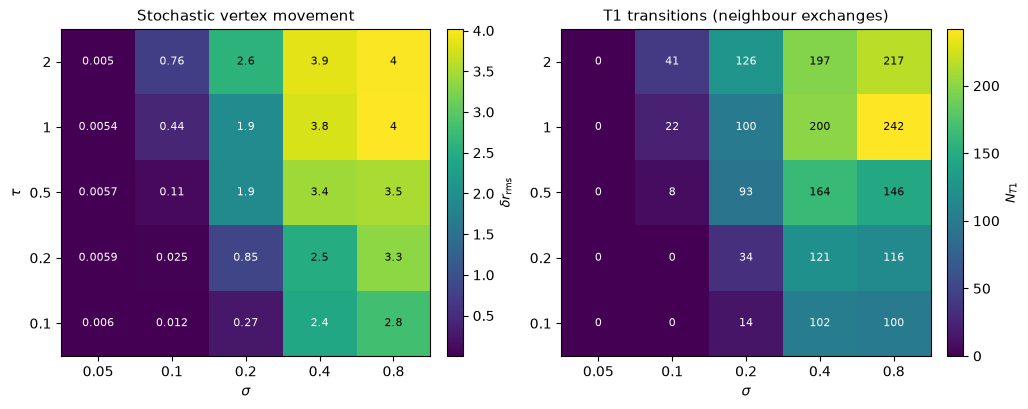

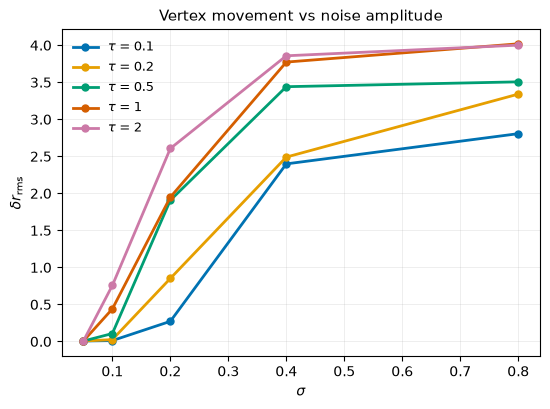

In [8]:
if not df.empty:
    df.to_csv(OUT_DIR / "metrics.csv", index=False)
    print("wrote", OUT_DIR / "metrics.csv")
    build_summary(df, OUT_DIR / "summary")
else:
    print("No archives found — run `python stochastic_tension.py` first.")